<a href="https://colab.research.google.com/github/Harshita-ami/Decode_labs/blob/main/DECODELABP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer

%matplotlib inline
#imports the necessary tools and libraries for EDA of the data set.

In [2]:
df = sns.load_dataset('titanic')
df.head()
#using the titanic dataset

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
print(df.shape)
df.info()
df.describe()
# basic EDA. Explains the dataset features

(891, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [4]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
pd.DataFrame({'Missing Count': missing, 'Missing %': missing_percent}).sort_values('Missing %', ascending=False)
#checks missing values and percentage of missing values..

,Missing Count,Missing %
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467
sex,0,0.000000
pclass,0,0.000000
survived,0,0.000000
fare,0,0.000000
parch,0,0.000000
sibsp,0,0.000000


In [5]:
# 'deck' has too many missing (~77%) -> drop the column entirely
df.drop(columns=['deck'], inplace=True)

# 'age' has moderate missing (~20%) -> fill with median
df['age'].fillna(df['age'].median(), inplace=True)

# 'embarked' and 'embark_town' have very few missing -> drop those rows
df.dropna(subset=['embarked', 'embark_town'], inplace=True)

# Confirm no missing values remain
df.isnull().sum()
#Handles the missing values

/tmp/ipykernel_6213/2204739364.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)


,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,0
class,0
who,0


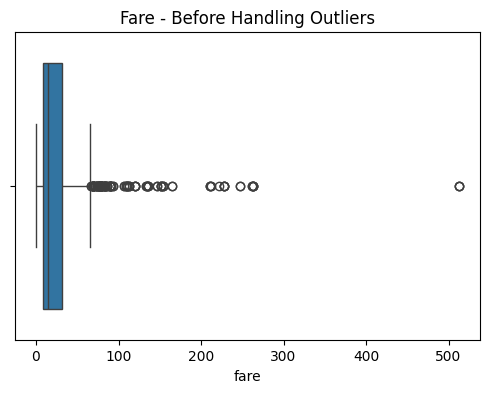

In [6]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['fare'])
plt.title('Fare - Before Handling Outliers')
plt.show() #before handling outliers

In [7]:
Q1 = df['fare'].quantile(0.25)
Q3 = df['fare'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Lower bound: {lower_bound}, Upper bound: {upper_bound}")

# Count outliers
outliers = df[(df['fare'] < lower_bound) | (df['fare'] > upper_bound)]
print(f"Number of outliers in 'fare': {len(outliers)}")

# Cap them instead of deleting rows
df['fare'] = np.clip(df['fare'], lower_bound, upper_bound)
#detect and cap outliers using iqr

Lower bound: -26.7605, Upper bound: 65.6563
Number of outliers in 'fare': 114


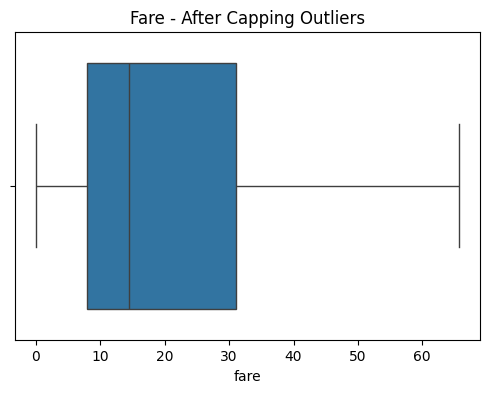

In [8]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df['fare'])
plt.title('Fare - After Capping Outliers')
plt.show()

In [9]:
# 1. FamilySize = siblings/spouses + parents/children + self
df['family_size'] = df['sibsp'] + df['parch'] + 1

# 2. IsAlone = 1 if traveling alone, else 0
df['is_alone'] = (df['family_size'] == 1).astype(int)

# 3. Extract Title from the 'who' or name-like info (Titanic via seaborn lacks 'Name', so we use 'who'/'adult_male' instead)
df['age_group'] = pd.cut(df['age'], bins=[0, 12, 18, 60, 100], labels=['Child', 'Teen', 'Adult', 'Senior'])

df[['family_size', 'is_alone', 'age_group']].head()

,family_size,is_alone,age_group
0,2,0,Adult
1,2,0,Adult
2,1,1,Adult
3,2,0,Adult
4,1,1,Adult


In [10]:
print("Missing values left:", df.isnull().sum().sum())
df.head()

Missing values left: 0


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,family_size,is_alone,age_group
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,2,0,Adult
1,1,1,female,38.0,1,0,65.6563,C,First,woman,False,Cherbourg,yes,False,2,0,Adult
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,1,1,Adult
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,2,0,Adult
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,1,1,Adult
